<a href="https://colab.research.google.com/github/Andoniadou-Lab/consensus_pituitary_atlas/blob/main/other/Curation_assigning_modality_to_samples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install packages

In [ ]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 117.9 MB/s eta 0:00:00


In [ ]:
!pip install epitome_tools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for epitome_tools: filename=epitome_tools-0.0.21-py3-none-any.whl size=36580399 sha256=5521f03253a4ad9cba7846d9a6ff2a2bed80872439a562255cb95f6932ec131d
  Stored in directory: /root/.cache/pip/wheels/38/37/e3/dae3dbc83f43370096637df8e74e883c79d76bb25bc995459e
Successfully built epitome_tools


In [ ]:
import anndata
import scanpy as sc

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)
df = pd.read_excel('/content/drive/MyDrive/pituitary_atlas/source_table/pituitary_atlas.xlsx')
pituitary_atlas = df.copy()
#only keep sn or sc for now
df = df[df['Modality'].isin(['sc','sn'])]
df = df[df['species'].isin(['mouse'])]
df.reset_index(drop=True, inplace=True)
#remove where Author is Rebboah et al. (2025)
df = df[df['Author'] != 'Rebboah et al. (2025)']
df
df

,GEO,SRA_ID,Name,Conditions,Normal,Background,Sorted,Author,DOI,Age,...,filtering_junk,median_cellassign_prob,most_recent_workflow,n_cells,processed_atac,passed_qc_tcc,tcc_pseudobulked,Core,Notes 1,Notes 2
0,GSM4594333,SRX8489818,M-Pituitary,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.0,v_0.01,1278.0,0.0,1.0,v_0.01,1,NaN,NaN
1,GSM4594334,SRX8489819,FM_Pit_1-1,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.0,v_0.01,8236.0,0.0,1.0,v_0.01,1,NaN,NaN
2,GSM4594335,SRX8489820,FM_Pit_1-2,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.0,v_0.01,7092.0,0.0,1.0,v_0.01,1,NaN,NaN
3,GSM4594336,SRX8489821,MM_Pit_4-1,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.0,v_0.01,1755.0,0.0,1.0,v_0.01,1,NaN,NaN
4,GSM4594337,SRX8489822,MM_Pit_1v2,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.0,v_0.01,416.0,0.0,1.0,v_0.01,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,GSM9302173,SRX31166359,"pituitary, HFD_2",High_fat_diet,1,Unclear,0,Guo et al. (2025),NaN,16 weeks,...,1.0,1.0,v_0.01,7193.0,NaN,NaN,NaN,1,NaN,NaN
212,GSM9302174,SRX31166360,"pituitary, ND_1",Normal_diet,0,Unclear,0,Guo et al. (2025),NaN,16 weeks,...,1.0,1.0,v_0.01,7298.0,NaN,NaN,NaN,1,NaN,NaN
213,GSM9302175,SRX31166361,"pituitary, ND_2",Normal_diet,0,Unclear,0,Guo et al. (2025),NaN,16 weeks,...,1.0,1.0,v_0.01,7530.0,NaN,NaN,NaN,1,NaN,NaN
214,NaN,SRX31798127,NaN,POMC-WT,1,C57BL/6J,0,Sochodolsky et al. (2026),NaN,386 days,...,1.0,1.0,v_0.01,8083.0,NaN,NaN,NaN,1,NaN,NaN


In [ ]:
df["Modality"].value_counts()

,count
Modality,
sc,124
sn,27


In [ ]:
df["assay_numeric"] = pd.Categorical(df["Modality"]).codes
df["assay_numeric"].value_counts()

,count
assay_numeric,
0,124
1,27


In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
from epitome_tools import atlas
import anndata

In [ ]:
assay=[]
pct_mito = []
pct_ribo = []
pct_malat = []
sra=[]
for i in range(len(df)):

  SRA_ID=df["SRA_ID"][i]
  print(SRA_ID)
  try:
    adata = anndata.read_mtx(f"/content/drive/MyDrive/pituitary_atlas/processed/nac/{SRA_ID}/analysis/out_45_cells_x_genes.total.mtx")
    adata.obs = pd.read_csv(f"/content/drive/MyDrive/pituitary_atlas/processed/nac/{SRA_ID}/analysis/out_45_cells_x_genes.barcodes.txt",header=None)
    adata.var = pd.read_csv(f"/content/drive/MyDrive/pituitary_atlas/processed/nac/{SRA_ID}/analysis/out_45_cells_x_genes.genes.names.txt",header=None)
    adata.var.index = [str(i) for i in adata.var[0].values]
    adata.var["feature_types"] = "mrna"
    adata.obs.index = [str(i) for i in adata.obs[0].values]

    adata = atlas.qc1(adata,"mouse")


    #pct_mito
    assay_numeric = df.loc[df['SRA_ID'] == SRA_ID, 'assay_numeric'].values[0]
    try:
      pctmito = np.mean(adata.obs["pct_counts_mt"])
    except:
      pctmito = 0
    #pctDdx3y
    try:
      pctribo = np.mean(adata.obs["pct_counts_ribo"])
    except:
      pctribo = 0
    #pctKdm5d
    try:
      pctmalat = np.mean(adata[:,"Malat1"].X.toarray())
      #log2
      pctmalat = np.log2(pctmalat)
    except:
      pctmalat = 0
    print(f"Assay: {assay_numeric}, pct_mito: {pctmito}, pct_ribo: {pctribo}, pct_malat: {pctmalat}")

    assay.append(assay_numeric)
    pct_mito.append(pctmito)
    pct_ribo.append(pctribo)
    pct_malat.append(pctmalat)

    sra.append(SRA_ID)
  except:
   print(f"No data for {SRA_ID}")

SRX8489818


/usr/local/lib/python3.12/dist-packages/anndata/__init__.py:70: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/anndata/__init__.py:70: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


Assay: 0, pct_mito: 2.602616310119629, pct_ribo: 8.873002052307129, pct_malat: 5.823315143585205
SRX8489819


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Assay: 0, pct_mito: 3.8685591220855713, pct_ribo: 6.366436958312988, pct_malat: 7.990573883056641
SRX8489820


...

Assay: 0, pct_mito: 2.8472037315368652, pct_ribo: 5.340120315551758, pct_malat: 7.626394271850586
SRX31798127


/usr/local/lib/python3.12/dist-packages/anndata/__init__.py:70: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Assay: 0, pct_mito: 3.590409994125366, pct_ribo: 6.297861576080322, pct_malat: 7.009720325469971
SRX31798126


/usr/local/lib/python3.12/dist-packages/anndata/__init__.py:70: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Assay: 0, pct_mito: 4.348260879516602, pct_ribo: 6.298017501831055, pct_malat: 7.805335521697998


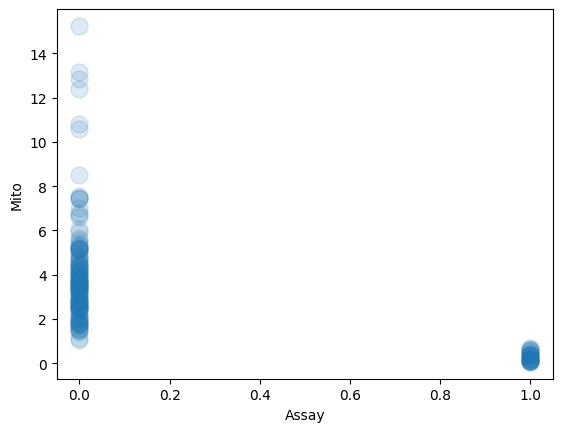

In [ ]:
#plot sex_numeric vs xist
import matplotlib.pyplot as plt
plt.scatter(assay, pct_mito,alpha=0.15,s=150)
plt.xlabel("Assay")
plt.ylabel("Mito")
plt.show()

In [ ]:
pct_mito[:5]

[np.float32(2.6026163),
 np.float32(3.8685591),
 np.float32(3.6620853),
 np.float32(4.7059765),
 np.float32(1.8400543)]

In [ ]:
pct_ribo[:5]

[np.float32(8.873002),
 np.float32(6.366437),
 np.float32(6.583418),
 np.float32(5.4432235),
 np.float32(7.097665)]

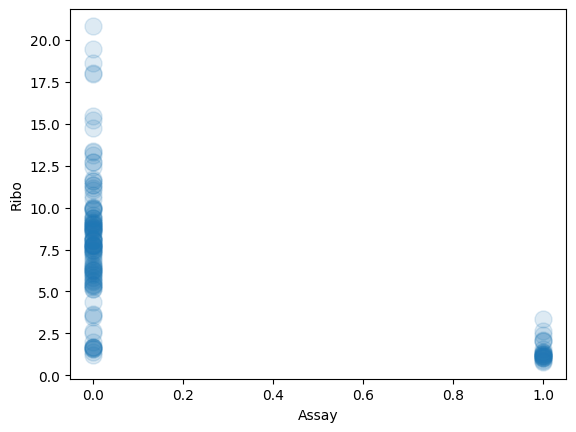

In [ ]:
#plot sex_numeric vs xist
import matplotlib.pyplot as plt
plt.scatter(assay, pct_ribo,alpha=0.15,s=150)
plt.xlabel("Assay")
plt.ylabel("Ribo")
plt.show()

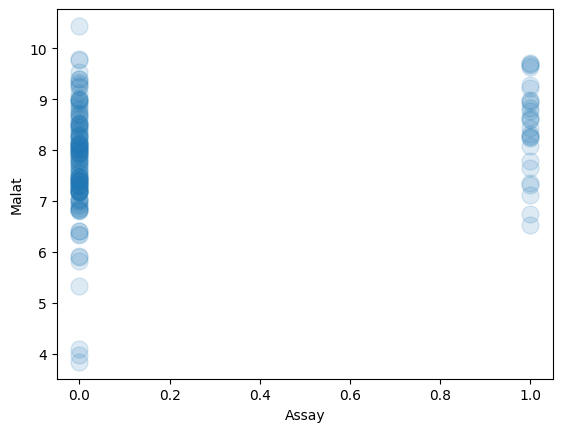

In [ ]:
#plot sex_numeric vs xist
import matplotlib.pyplot as plt
plt.scatter(assay, pct_malat,alpha=0.15,s=150)
plt.xlabel("Assay")
plt.ylabel("Malat")
plt.show()

In [ ]:
y_known

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int8)

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Convert lists to numpy arrays
assay = np.array(assay)
X = np.column_stack((pct_mito, pct_ribo, pct_malat))

# Split data into known and unknown sex
#if assay is not 0 or 1, set it to -1
assay[(assay!=0) & (assay!=1)] = -1


known_indices = assay != -1
unknown_indices = assay == -1

X_known = X[known_indices]
y_known = assay[known_indices]

# Split known data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_known, y_known, test_size=0.3, random_state=42)

# Create and train the logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



# If you want to update the original assay list with predictions
new_assay = assay.copy()
print("\nUpdated assay list:")
print(new_assay)

Model Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        11

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46


Updated assay list:
[0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0
 0 0 0]


In [ ]:
assay

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int8)

In [ ]:
# Evaluate on the entire dataset to check for mislabeling
all_predictions = model.predict(X)
mislabeled_indices = np.where((assay != -1) & (all_predictions != assay))[0]

print("\nPotentially Mislabeled Datapoints:")
if len(mislabeled_indices) > 0:
    for idx in mislabeled_indices:
        print(f"Index: {idx}, Original Label: {1 if assay[idx] == 0 else 0}")
        print(
              f"Predicted Label: {"sc" if all_predictions[idx] == 1 else "sn"}")
        print(f"   Mito {X[idx][0]}, Ribo {X[idx][1]}, Malat {X[idx][2]}")
else:
    print("No potentially mislabeled datapoints found.")

print(f"\nTotal number of potentially mislabeled datapoints: {len(mislabeled_indices)}")

#print sra ids
print("\nSRA IDs:")
for idx in mislabeled_indices:
    print(sra[idx])


Potentially Mislabeled Datapoints:
Index: 25, Original Label: 1
Predicted Label: sc
   Mito 1.7022511959075928, Ribo 1.2153114080429077, Malat 8.102422714233398

Total number of potentially mislabeled datapoints: 1

SRA IDs:
SRX7874741


# Plotting Mito vs logistic regression score.

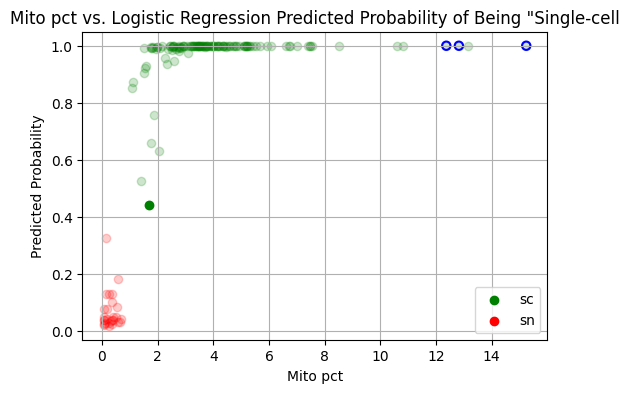

In [ ]:
y_pred_proba = model.predict_proba(X_known)[:, 1]
y_pred = model.predict(X_known)

# Extract pct_xist values for the test set
xist_pct_test = X[:, 0]

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({
    'mito_pct': np.array(pct_mito)[known_indices],
    'predicted_prob': 1-y_pred_proba,
    'real_value': y_known,
    'predicted_value': y_pred,
    'sra_id': np.array(sra)[known_indices],
})

#remove those where SRA_ID ends with _01
plot_df = plot_df[~plot_df['sra_id'].astype(str).str.endswith('_01')]

# Create a column for coloring based on prediction accuracy
plot_df['color'] = np.where(plot_df['real_value'] == 1, 'green', 'red')
plot_df['prediction_status'] = np.where(plot_df['real_value'] == 1, 'sn','sc')

# Create the scatter plot
plt.figure(figsize=(6, 4))

# Plot correct predictions in green
correct_df = plot_df[plot_df['prediction_status'] == 'sc']
plt.scatter(correct_df['mito_pct'], correct_df['predicted_prob'], color='green', alpha=0.2)

# Plot incorrect predictions in red
incorrect_df = plot_df[plot_df['prediction_status'] == 'sn']
plt.scatter(incorrect_df['mito_pct'], incorrect_df['predicted_prob'], color='red',alpha=0.2)

#keep where real value doesnt match predicted_value
mislabeled_df = plot_df[plot_df['real_value'] != plot_df['predicted_value']]
# Plot correct predictions in green
correct_df = mislabeled_df[mislabeled_df['prediction_status'] == 'sc']
plt.scatter(correct_df['mito_pct'], correct_df['predicted_prob'], color='green', label='sc',alpha=1)

# Plot incorrect predictions in red
incorrect_df = mislabeled_df[mislabeled_df['prediction_status'] == 'sn']
plt.scatter(incorrect_df['mito_pct'], incorrect_df['predicted_prob'], color='red', label='sn',alpha=1)

highlight = plot_df[plot_df['sra_id'].isin(['SRX8489840', 'SRX8489841', 'SRX8489842'])]
plt.scatter(highlight['mito_pct'], highlight['predicted_prob'], edgecolors='blue', linewidths=1.5, facecolors='none')
plt.title('Mito pct vs. Logistic Regression Predicted Probability of Being "Single-cell"')
plt.xlabel('Mito pct')
plt.ylabel('Predicted Probability')
plt.grid(True)
plt.legend()
# Save the plot
plt.savefig('mito_vs_logistic_regression_original.png')

# Plotting Ribo vs logistic regression score.

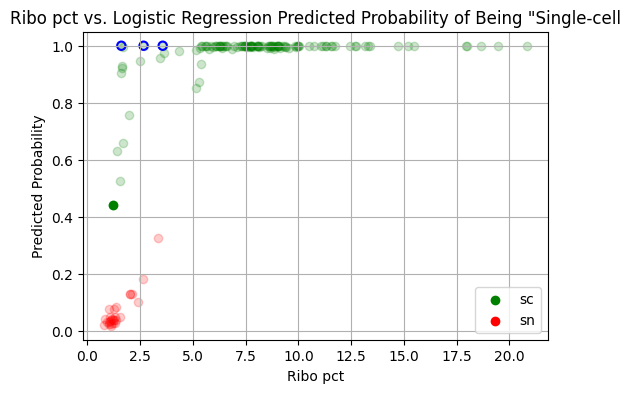

In [ ]:
y_pred_proba = model.predict_proba(X_known)[:, 1]
y_pred = model.predict(X_known)

# Extract pct_xist values for the test set
xist_pct_test = X[:, 0]

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({
    'ribo_pct': np.array(pct_ribo)[known_indices],
    'predicted_prob': 1-y_pred_proba,
    'real_value': y_known,
    'predicted_value': y_pred,
    'sra_id': np.array(sra)[known_indices],
})

#remove those where SRA_ID ends with _01
plot_df = plot_df[~plot_df['sra_id'].astype(str).str.endswith('_01')]

# Create a column for coloring based on prediction accuracy
plot_df['color'] = np.where(plot_df['real_value'] == 1, 'green', 'red')
plot_df['prediction_status'] = np.where(plot_df['real_value'] == 1, 'sn','sc')

# Create the scatter plot
plt.figure(figsize=(6, 4))

# Plot correct predictions in green
correct_df = plot_df[plot_df['prediction_status'] == 'sc']
plt.scatter(correct_df['ribo_pct'], correct_df['predicted_prob'], color='green', alpha=0.2)

# Plot incorrect predictions in red
incorrect_df = plot_df[plot_df['prediction_status'] == 'sn']
plt.scatter(incorrect_df['ribo_pct'], incorrect_df['predicted_prob'], color='red',alpha=0.2)

#keep where real value doesnt match predicted_value
mislabeled_df = plot_df[plot_df['real_value'] != plot_df['predicted_value']]
# Plot correct predictions in green
correct_df = mislabeled_df[mislabeled_df['prediction_status'] == 'sc']
plt.scatter(correct_df['ribo_pct'], correct_df['predicted_prob'], color='green', label='sc',alpha=1)

# Plot incorrect predictions in red
incorrect_df = mislabeled_df[mislabeled_df['prediction_status'] == 'sn']
plt.scatter(incorrect_df['ribo_pct'], incorrect_df['predicted_prob'], color='red', label='sn',alpha=1)

highlight = plot_df[plot_df['sra_id'].isin(['SRX8489840', 'SRX8489841', 'SRX8489842'])]
plt.scatter(highlight['ribo_pct'], highlight['predicted_prob'], edgecolors='blue', linewidths=1.5, facecolors='none')

plt.title('Ribo pct vs. Logistic Regression Predicted Probability of Being "Single-cell"')
plt.xlabel('Ribo pct')
plt.ylabel('Predicted Probability')
plt.grid(True)
plt.legend()
# Save the plot
plt.savefig('ribo_vs_logistic_regression_original.png')

# Plotting log2 Malat1 vs logistic regression score.

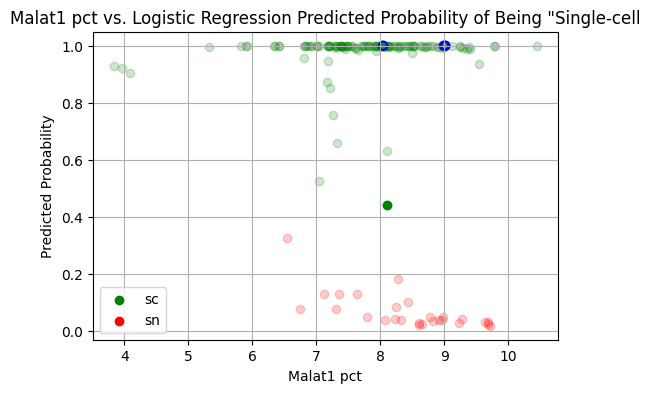

In [ ]:
y_pred_proba = model.predict_proba(X_known)[:, 1]
y_pred = model.predict(X_known)

# Extract pct_xist values for the test set
xist_pct_test = X[:, 0]

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({
    'malat_pct': np.array(pct_malat)[known_indices],
    'predicted_prob': 1-y_pred_proba,
    'real_value': y_known,
    'predicted_value': y_pred,
    'sra_id': np.array(sra)[known_indices],
})

#remove those where SRA_ID ends with _01
plot_df = plot_df[~plot_df['sra_id'].astype(str).str.endswith('_01')]

# Create a column for coloring based on prediction accuracy
plot_df['color'] = np.where(plot_df['real_value'] == 1, 'green', 'red')
plot_df['prediction_status'] = np.where(plot_df['real_value'] == 1, 'sn','sc')

# Create the scatter plot
plt.figure(figsize=(6, 4))

# Plot correct predictions in green
correct_df = plot_df[plot_df['prediction_status'] == 'sc']
plt.scatter(correct_df['malat_pct'], correct_df['predicted_prob'], color='green', alpha=0.2)

# Plot incorrect predictions in red
incorrect_df = plot_df[plot_df['prediction_status'] == 'sn']
plt.scatter(incorrect_df['malat_pct'], incorrect_df['predicted_prob'], color='red',alpha=0.2)

#keep where real value doesnt match predicted_value
mislabeled_df = plot_df[plot_df['real_value'] != plot_df['predicted_value']]
# Plot correct predictions in green
correct_df = mislabeled_df[mislabeled_df['prediction_status'] == 'sc']
plt.scatter(correct_df['malat_pct'], correct_df['predicted_prob'], color='green', label='sc',alpha=1)

# Plot incorrect predictions in red
incorrect_df = mislabeled_df[mislabeled_df['prediction_status'] == 'sn']
plt.scatter(incorrect_df['malat_pct'], incorrect_df['predicted_prob'], color='red', label='sn',alpha=1)

highlight = plot_df[plot_df['sra_id'].isin(['SRX8489840', 'SRX8489841', 'SRX8489842'])]
plt.scatter(highlight['malat_pct'], highlight['predicted_prob'], edgecolors='blue', linewidths=1.5, facecolors='none')


plt.title('Malat1 pct vs. Logistic Regression Predicted Probability of Being "Single-cell"')
plt.xlabel('Malat1 pct')
plt.ylabel('Predicted Probability')
plt.grid(True)
plt.legend()
# Save the plot
plt.savefig('ribo_vs_logistic_regression_original.png')

In [ ]:
plot_df[plot_df["sra_id"].isin(["SRX21170825","SRX21986110","SRX21986112","SRX29174028","SRX29174029"])]

,xist_pct,predicted_prob,real_value,predicted_value,sra_id,color,prediction_status
47,0.202532,0.150509,0.0,1.0,SRX21170825,green,Male
53,0.002765,0.085211,0.0,1.0,SRX21986110,green,Male
55,0.555357,0.710437,1.0,0.0,SRX21986112,red,Female
202,0.003899,0.088787,0.0,1.0,SRX29174028,green,Male
203,0.998861,0.941567,1.0,0.0,SRX29174029,red,Female


In [ ]:
len(all_predictions)

229

In [ ]:
#at least the first two of these, overwrite the sex values with predictions
new_sex[mislabeled_indices] = all_predictions[mislabeled_indices]

In [ ]:
#iterate through sra ids and add these vals back to df into column "Comp_sex"
df = pd.read_excel('/content/drive/MyDrive/pituitary_atlas/source_table/pituitary_atlas.xlsx')
for s in range(len(sra)):
  df.loc[df['SRA_ID'] == sra[s], 'Comp_sex'] = new_sex[s]
#save
df.to_excel('/content/drive/MyDrive/pituitary_atlas/source_table/pituitary_atlas.xlsx', index=False)

In [ ]:
#print subtable of values where Sex_numeric and Comp_sex differ
#show all rows
pd.set_option('display.max_rows', None)
sub_df = df[(df['Sex_numeric'] != df['Comp_sex'])]
#show SRA_ID, Sex_numeric and Comp_sex
sub_df = sub_df[['SRA_ID', 'Sex_numeric', 'Comp_sex']]
sub_df

,SRA_ID,Sex_numeric,Comp_sex
54,ERX7593481,0.50,1.0
55,ERX7593482,0.50,0.0
56,ERX7593483,0.50,1.0
57,ERX7593484,0.50,1.0
60,SRX21170825,0.00,1.0
66,SRX21986110,0.00,1.0
68,SRX21986112,1.00,0.0
98,SRX15581371,0.75,0.0
101,SRX8497092,-1.00,1.0
102,SRX8497093,-1.00,0.0


In [ ]:
!pip freeze

absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.10.1
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.0
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.16.5
altair==5.5.0
anndata==0.12.2
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.11.0
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array-api-compat==1.12.0
array_record==0.8.1
arrow==1.3.0
arviz==0.22.0
astropy==7.1.0
astropy-iers-data==0.2025.10.6.0.35.25
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.0.1
Authlib==1.6.5
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.2
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.24.0
bigquery-magics==0.10.3
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.1.0
blosc2==3.10.0
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
Brotli==1.1.0
build==1.3.0
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.10.5
cffi==2.0.0
chardet==5.2.0
c